In [57]:
import torch
import pandas as pd
from datasets import load_dataset
import os
from transformers import AutoTokenizer
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from transformers import AutoModelForSequenceClassification
from transformers import TrainingArguments
from transformers import Trainer
from transformers import AutoConfig
from evaluate import load
import matplotlib.pyplot as plt
from torch import nn

In [58]:
#data_path = "/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/test_read_training_data_right_classifications/paragraph_and_sentence_len_5_min_chunk_len_100_cos_thresh_0.4_nace_level_1_stoxx_with_null/"
data_path = "/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/test_read_training_data/paragraph_and_sentence_len_5_min_chunk_len_100_cos_thresh_0.4_nace_level_1_stoxx_with_no_class/"
data_path = "/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/training_data/paragraph_and_sentence_len_4_min_chunk_len_100_cos_thresh_0.4_nace_level_1_stoxx/"
data_path = "/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/test_read_training_data/paragraph_and_sentence_len_5_min_chunk_len_100_cos_thresh_0.4_nace_level_1_stoxx_with_no_class__cos_sim_04/"
data_path = "/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/training_data/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1__sample_ratio_1__filter_only_right_chunks_labeling"

In [59]:
train_df = pd.read_csv(os.path.join(data_path, "train_data.csv"))

In [ ]:
# Load a custom CSV file
data_files = {"train": os.path.join(data_path, "train_data.csv"), "test": os.path.join(data_path, "test_data.csv"), "validation": os.path.join(data_path, "val_data.csv")}
dataset = load_dataset("csv", data_files=data_files)
label_mapping = {char: val for val, char in enumerate(['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q','R','S','T','U',"NO_CLASS"])}
dataset = dataset.map(lambda x: {"label": label_mapping[x["NACE_Code"]]})

print(dataset["train"][0])

{'Evaluation': None, 'Notes': None, 'text': 'the procurement process of raw materials for the mechanical construction seeks from several suppliersr. the company has no policy to buy from any single supplier. the raw materials procured for the companys operation can be classied into types as follows.', 'Score': 0.5356489539904472, 'NACE_Code': 'F', 'label': 5}


In [21]:
dataset["train"]

Dataset({
    features: ['Evaluation', 'Notes', 'text', 'Score', 'NACE_Code', 'label'],
    num_rows: 35499
})

In [22]:
# Initialize the BERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Tokenize a sample text
sample_text = dataset["train"][0]["text"]
tokens = tokenizer(sample_text, padding="max_length", truncation=True, max_length=128)

print(tokens)


{'input_ids': [101, 1996, 21423, 2832, 1997, 6315, 4475, 2005, 1996, 6228, 2810, 11014, 2013, 2195, 20141, 2099, 1012, 1996, 2194, 2038, 2053, 3343, 2000, 4965, 2013, 2151, 2309, 17024, 1012, 1996, 6315, 4475, 4013, 19405, 2005, 1996, 2194, 2015, 3169, 2064, 2022, 2465, 6340, 2046, 4127, 2004, 4076, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [23]:
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# Apply the tokenizer to the dataset
tokenized_datasets = dataset.map(tokenize_function, batched=True)

# Inspect tokenized samples
print(tokenized_datasets["train"][0])

{'Evaluation': None, 'Notes': None, 'text': 'the procurement process of raw materials for the mechanical construction seeks from several suppliersr. the company has no policy to buy from any single supplier. the raw materials procured for the companys operation can be classied into types as follows.', 'Score': 0.5356489539904472, 'NACE_Code': 'F', 'label': 5, 'input_ids': [101, 1996, 21423, 2832, 1997, 6315, 4475, 2005, 1996, 6228, 2810, 11014, 2013, 2195, 20141, 2099, 1012, 1996, 2194, 2038, 2053, 3343, 2000, 4965, 2013, 2151, 2309, 17024, 1012, 1996, 6315, 4475, 4013, 19405, 2005, 1996, 2194, 2015, 3169, 2064, 2022, 2465, 6340, 2046, 4127, 2004, 4076, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [24]:
labels = dataset["train"]["label"]
class_weights = compute_class_weight("balanced", classes=np.unique(labels), y=labels)
print(class_weights)

[ 2.64641419  0.66277702  1.47463964  0.58883341  1.20075091  0.54903568
  0.58994898  0.54742702  1.22115583  2.77205997  0.33465313  0.54968179
  1.56873923  1.00558042  2.51801674  3.16672614 12.53938538  7.32693498
 77.84868421]


In [25]:
# Initialize a BERT model for binary classification
model_name = "bert-base-uncased"
config = AutoConfig.from_pretrained(model_name, num_labels=len(set(labels)))
model = AutoModelForSequenceClassification.from_pretrained(model_name, config=config)

print(model.config)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertConfig {
  "_attn_implementation_autoset": true,
  "_name_or_path": "bert-base-uncased",
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2",
    "3": "LABEL_3",
    "4": "LABEL_4",
    "5": "LABEL_5",
    "6": "LABEL_6",
    "7": "LABEL_7",
    "8": "LABEL_8",
    "9": "LABEL_9",
    "10": "LABEL_10",
    "11": "LABEL_11",
    "12": "LABEL_12",
    "13": "LABEL_13",
    "14": "LABEL_14",
    "15": "LABEL_15",
    "16": "LABEL_16",
    "17": "LABEL_17",
    "18": "LABEL_18"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_10": 10,
    "LABEL_11": 11,
    "LABEL_12": 12,
    "LABEL_13": 13,
    "LABEL_14": 14,
    "LABEL_15": 15,
    "LABEL_16": 16,
    "LABEL_

In [26]:
hidden = 512
model.classifier = nn.Sequential(
    nn.Linear(config.hidden_size, hidden),
    nn.GELU(),
    nn.Dropout(0.2),
    nn.Linear(hidden, config.num_labels),
)

In [27]:
for param in model.bert.parameters():
    param.requires_grad = False
    #param.requires_grad = True # Train the wmbeddings as well!

# Keep only the classification head trainable
for param in model.classifier.parameters():
    param.requires_grad = True

print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")


Trainable parameters: 403475


In [28]:
# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",          # Directory for saving model checkpoints
    evaluation_strategy="epoch",     # Evaluate at the end of each epoch
    learning_rate=5e-5,              # Start with a small learning rate
    per_device_train_batch_size=16,  # Batch size per GPU
    per_device_eval_batch_size=16,
    use_mps_device=True,             # <— key switch
    num_train_epochs=3,              # Number of epochs
    weight_decay=0.01,               # Regularization
    save_total_limit=2,              # Limit checkpoints to save space
    load_best_model_at_end=True,     # Automatically load the best checkpoint
    logging_dir="./logs",            # Directory for logs
    logging_strategy="epoch",            # Directory for logs
    logging_steps=100,               # Log every 100 steps
    #fp16=True,                      # Enable mixed precision for faster training
    save_strategy="epoch"
)

print(training_args)


TrainingArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=False,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
dispatch_batches=None,
do_eval=True,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=epoch,
eval_use_gather_object

/Users/hendrikweichel/miniconda3/envs/remedi/lib/python3.10/site-packages/transformers/training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/Users/hendrikweichel/miniconda3/envs/remedi/lib/python3.10/site-packages/transformers/training_args.py:2262: UserWarning: `use_mps_device` is deprecated and will be removed in version 5.0 of 🤗 Transformers. `mps` device will be used by default if available similar to the way `cuda` device is used.Therefore, no action from user is required. 
  warnings.warn(


In [29]:
# Load a metric (F1-score in this case)
metric = load("f1")

# Define a custom compute_metrics function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    return metric.compute(predictions=predictions, references=labels, average="weighted")

In [30]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
data_collator

DataCollatorWithPadding(tokenizer=BertTokenizerFast(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
), padding=True, max_length=None, pad_to_multiple_of=None, return_tensors='pt')

In [31]:
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

In [32]:
import torch
import torch.nn as nn
from transformers import Trainer

class WeightedCELossTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = (
            torch.as_tensor(class_weights, dtype=torch.float32) if class_weights is not None else None
        )

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs["labels"]                 # shape [B], dtype long
        outputs = model(**{k: v for k, v in inputs.items() if k != "labels"})
        logits  = outputs.logits                  # [B, C]
        loss_fn = nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device) if self.class_weights is not None else None
        )
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [33]:
trainer = WeightedCELossTrainer(
    model=model,                        # Pre-trained BERT model
    args=training_args,                 # Training arguments
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,        # Efficient batching
    class_weights=class_weights,   # <— here’s A
    compute_metrics=compute_metrics     # Custom metric
)

/var/folders/fp/yhl61lbj3m73x3_17tsp1vrr0000gn/T/ipykernel_20243/2231333852.py:7: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedCELossTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


In [34]:
# Start trainingO
trainer.train()

/Users/hendrikweichel/miniconda3/envs/remedi/lib/python3.10/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,F1
1,2.820200,2.751566,0.139587
2,2.686500,2.648202,0.221733
3,2.623600,2.594635,0.233137


/Users/hendrikweichel/miniconda3/envs/remedi/lib/python3.10/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/hendrikweichel/miniconda3/envs/remedi/lib/python3.10/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/hendrikweichel/miniconda3/envs/remedi/lib/python3.10/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=6657, training_loss=2.710126118418582, metrics={'train_runtime': 1286.6192, 'train_samples_per_second': 82.773, 'train_steps_per_second': 5.174, 'total_flos': 7038008820709632.0, 'train_loss': 2.710126118418582, 'epoch': 3.0})

In [35]:
import pandas as pd
logs = pd.DataFrame(trainer.state.log_history)
logs.head()

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,2.8202,4.639800,0.000033,1.0,2219,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,2219,2.751566,0.139587,96.7101,122.366,7.652,NaN,NaN,NaN,NaN,NaN
2,2.6865,16.517467,0.000017,2.0,4438,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,4438,2.648202,0.221733,92.4170,128.050,8.007,NaN,NaN,NaN,NaN,NaN
4,2.6236,7.614252,0.000000,3.0,6657,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
logs["epoch"]

0    1.0
1    1.0
2    2.0
3    2.0
4    3.0
5    3.0
6    3.0
Name: epoch, dtype: float64

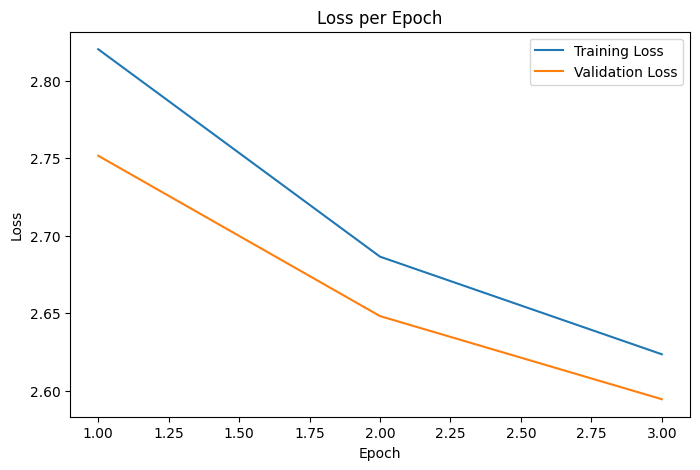

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
logs_epoch = logs.dropna(subset="loss")
eval_loss_epoch = logs.dropna(subset="eval_loss")
plt.plot(logs_epoch["epoch"], logs_epoch["loss"], label="Training Loss")
if "eval_loss" in logs:
    plt.plot(eval_loss_epoch["epoch"], eval_loss_epoch["eval_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss per Epoch")
plt.legend()
plt.show()

In [45]:
# Evaluate the model
results = trainer.evaluate()
print(results)

/Users/hendrikweichel/miniconda3/envs/remedi/lib/python3.10/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 2.594635486602783, 'eval_f1': 0.23313740642841974, 'eval_runtime': 100.0439, 'eval_samples_per_second': 118.288, 'eval_steps_per_second': 7.397, 'epoch': 3.0}


In [46]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Generate predictions
predictions = trainer.predict(tokenized_datasets["test"])
predicted_labels = predictions.predictions.argmax(axis=-1)

# Classification report
print(classification_report(tokenized_datasets["test"]["label"], predicted_labels))

/Users/hendrikweichel/miniconda3/envs/remedi/lib/python3.10/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


              precision    recall  f1-score   support

           0       0.67      0.03      0.06       255
           1       0.45      0.60      0.51       963
           2       0.15      0.12      0.13       424
           3       0.37      0.19      0.25      1091
           4       0.24      0.22      0.23       538
           5       0.31      0.08      0.13      1087
           6       0.23      0.07      0.11      1078
           7       0.55      0.11      0.18      1172
           8       0.23      0.09      0.12       527
           9       0.67      0.01      0.02       222
          10       0.37      0.58      0.45      1786
          11       0.29      0.22      0.25      1104
          12       0.20      0.00      0.01       413
          13       0.15      0.06      0.09       612
          14       0.00      0.00      0.00         0
          15       0.14      0.44      0.21       234
          16       0.05      0.87      0.09       180
          17       0.00    

/Users/hendrikweichel/miniconda3/envs/remedi/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hendrikweichel/miniconda3/envs/remedi/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hendrikweichel/miniconda3/envs/remedi/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

In [ ]:
label_mapping = {char: val for val, char in enumerate(set(train_df["NACE_Code"]))}

In [66]:
len(list(label_mapping.keys()))

19

In [63]:
predicted_labels

array([ 1,  3, 10, ..., 10, 16,  3])

ValueError: The number of FixedLocator locations (20), usually from a call to set_ticks, does not match the number of labels (19).

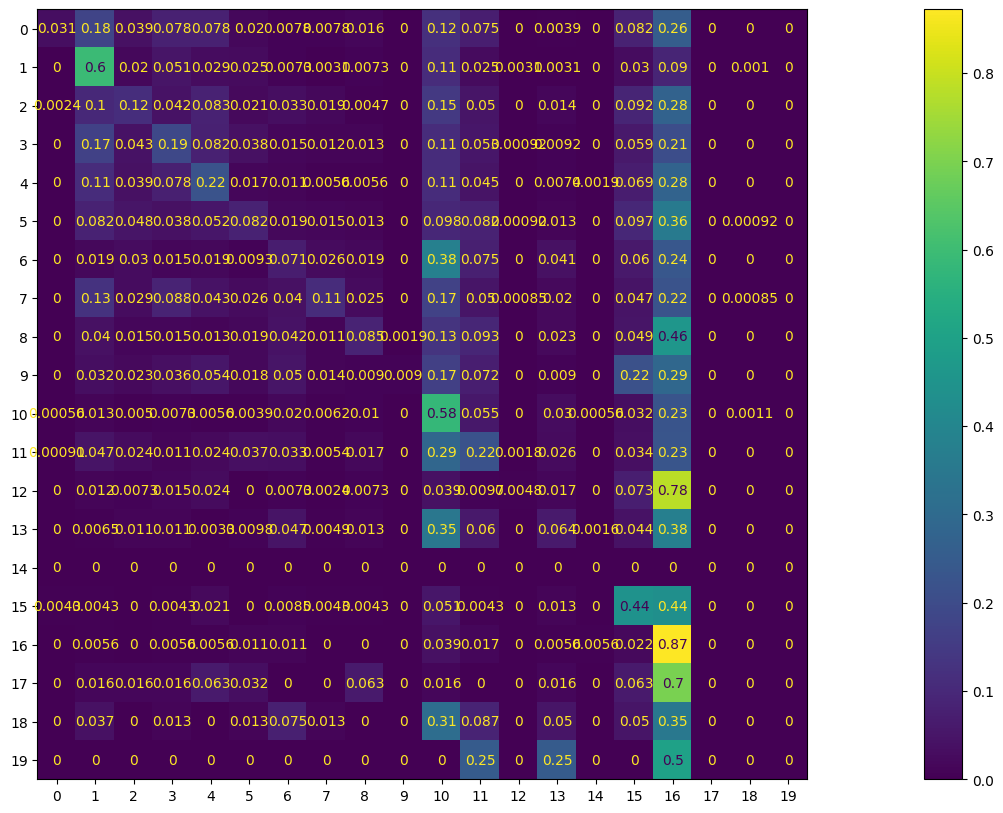

In [ ]:
# Confusion matrix
cm = confusion_matrix(tokenized_datasets["test"]["label"], predicted_labels, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[key for key, _ in sorted(label_mapping.items(), key=lambda item: item[1])])
#disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(30, 10))  # <-- set size here
disp.plot(ax=ax, xticks_rotation="vertical")
plt.show()


In [ ]:
ckpt = "results/checkpoint-5668"
final_dir = "my_model_final"  

model = AutoModelForSequenceClassification.from_pretrained(ckpt)
tokenizer = AutoTokenizer.from_pretrained(ckpt)

# model.save_pretrained(final_dir)         # writes config + model.safetensors (or pytorch_model.bin)
# tokenizer.save_pretrained(final_dir)     # writes tokenizer files

('my_model_final/tokenizer_config.json',
 'my_model_final/special_tokens_map.json',
 'my_model_final/vocab.txt',
 'my_model_final/added_tokens.json',
 'my_model_final/tokenizer.json')

In [ ]:
sentenec = "all manufacturing of secondary aluminium is defined by the taxonomy as making a substantial contribution to climate change mitigation. to be a taxonomyaligned activity the manufacture of secondary aluminium must also comply with the dnsh criteria for manufacture of aluminium and hydro must comply with the criteria for processes and outcomes related to human rights bribery and corruption taxation and fair competition minimum safeguards."
sentenec = "all manufacturing of secondary aluminium is defined by the taxonomy as making a substantial contribution to climate change mitigation. to be a taxonomyaligned activity the manufacture of secondary aluminium must also comply with the dnsh criteria for manufacture of aluminium and hydro must comply with the criteria for processes and outcomes related to human rights bribery and corruption taxation and fair competition minimum safeguards."
sentenec = "i. regasification basic and secondary transmission as well as storage of natural gas via the corresponding gas infrastructure or facilities of its own or of third parties and also the performance of auxiliary activities or others related to the aforementioned activities."
inputs = tokenizer(sentenec, return_tensors="pt")
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    predictions = torch.argmax(logits, dim=-1)

In [ ]:
# If you set id2label in config earlier, you can get human-readable labels
label = model.config.id2label[predictions.item()]
print("Predicted label:", label)

Predicted label: LABEL_3
